In [54]:
!pip install -q segmentation-models-pytorch albumentations

In [55]:
# Standard libraries
import os
import cv2
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

# Deep learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# Segmentation model + augmentation
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2

# GPU setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
print(f'GPU    : {torch.cuda.get_device_name(0)}')

# Reproducibility — same seed as my paper experiments
torch.manual_seed(42)
np.random.seed(42)
torch.backends.cudnn.benchmark = True
print('Setup complete!')

Device : cuda
GPU    : Tesla T4
Setup complete!


In [56]:
import os

base = '/kaggle/input/competitions/tgs-salt-identification-challenge'
for root, dirs, files in os.walk(base):
    depth = root.replace(base, '').count(os.sep)
    if depth < 4:
        print(f'{root}  ({len(files)} files)')

/kaggle/input/competitions/tgs-salt-identification-challenge  (7 files)


In [57]:
import os

base = '/kaggle/input/competitions/tgs-salt-identification-challenge'
for f in os.listdir(base):
    print(f)

depths.csv
sample_submission.csv
train.zip
competition_data.zip
test.zip
train.csv
flamingo.zip


In [58]:
import zipfile
import os

base = '/kaggle/input/competitions/tgs-salt-identification-challenge'
out  = '/kaggle/working/tgs_data'
os.makedirs(out, exist_ok=True)

# Unzip train.zip
print('Unzipping train.zip...')
with zipfile.ZipFile(f'{base}/train.zip', 'r') as z:
    z.extractall(out)
print('Done!')

# Check what we got
for root, dirs, files in os.walk(out):
    depth = root.replace(out, '').count(os.sep)
    if depth < 3:
        print(f'{root}  ({len(files)} files)')

Unzipping train.zip...
Done!
/kaggle/working/tgs_data  (0 files)
/kaggle/working/tgs_data/masks  (4000 files)
/kaggle/working/tgs_data/images  (4000 files)


In [59]:
import os

out = '/kaggle/working/tgs_data'
for root, dirs, files in os.walk(out):
    depth = root.replace(out, '').count(os.sep)
    if depth < 4:
        print(f'{root}  ({len(files)} files)')

/kaggle/working/tgs_data  (0 files)
/kaggle/working/tgs_data/masks  (4000 files)
/kaggle/working/tgs_data/images  (4000 files)


In [60]:
IMG_H   = 128
IMG_W   = 128
CLASSES = 1
BS      = 32
EPOCHS  = 60
LR      = 1e-3
THR     = 0.5
SEED    = 42

DATA  = '/kaggle/working/tgs_data'
IMGS  = f'{DATA}/images'
MASKS = f'{DATA}/masks'
CSV   = '/kaggle/input/competitions/tgs-salt-identification-challenge/train.csv'
OUT   = '/kaggle/working/outputs'
os.makedirs(OUT, exist_ok=True)

print(f'Train images : {len(os.listdir(IMGS)):,}')
print(f'Train masks  : {len(os.listdir(MASKS)):,}')
print(f'Epochs       : {EPOCHS}  Batch : {BS}')

Train images : 4,000
Train masks  : 4,000
Epochs       : 60  Batch : 32


In [61]:
df = pd.read_csv(CSV)

# Check how many images have salt vs empty
df['has_salt'] = df['id'].apply(lambda x:
    cv2.imread(os.path.join(MASKS, f'{x}.png'), cv2.IMREAD_GRAYSCALE).max() > 0
)

total = len(df)
salt  = df['has_salt'].sum()
empty = total - salt

print(f'Total images  : {total:,}')
print(f'Has salt      : {salt:,}  ({100*salt/total:.1f}%)')
print(f'Empty (no salt): {empty:,}  ({100*empty/total:.1f}%)')
print(df.head())

Total images  : 4,000
Has salt      : 2,438  (61.0%)
Empty (no salt): 1,562  (39.0%)
           id                                           rle_mask  has_salt
0  575d24d81d                                                NaN     False
1  a266a2a9df                                          5051 5151      True
2  75efad62c1  9 93 109 94 210 94 310 95 411 95 511 96 612 96...      True
3  34e51dba6a  48 54 149 54 251 53 353 52 455 51 557 50 659 4...      True
4  4875705fb0  1111 1 1212 1 1313 1 1414 1 1514 2 1615 2 1716...      True


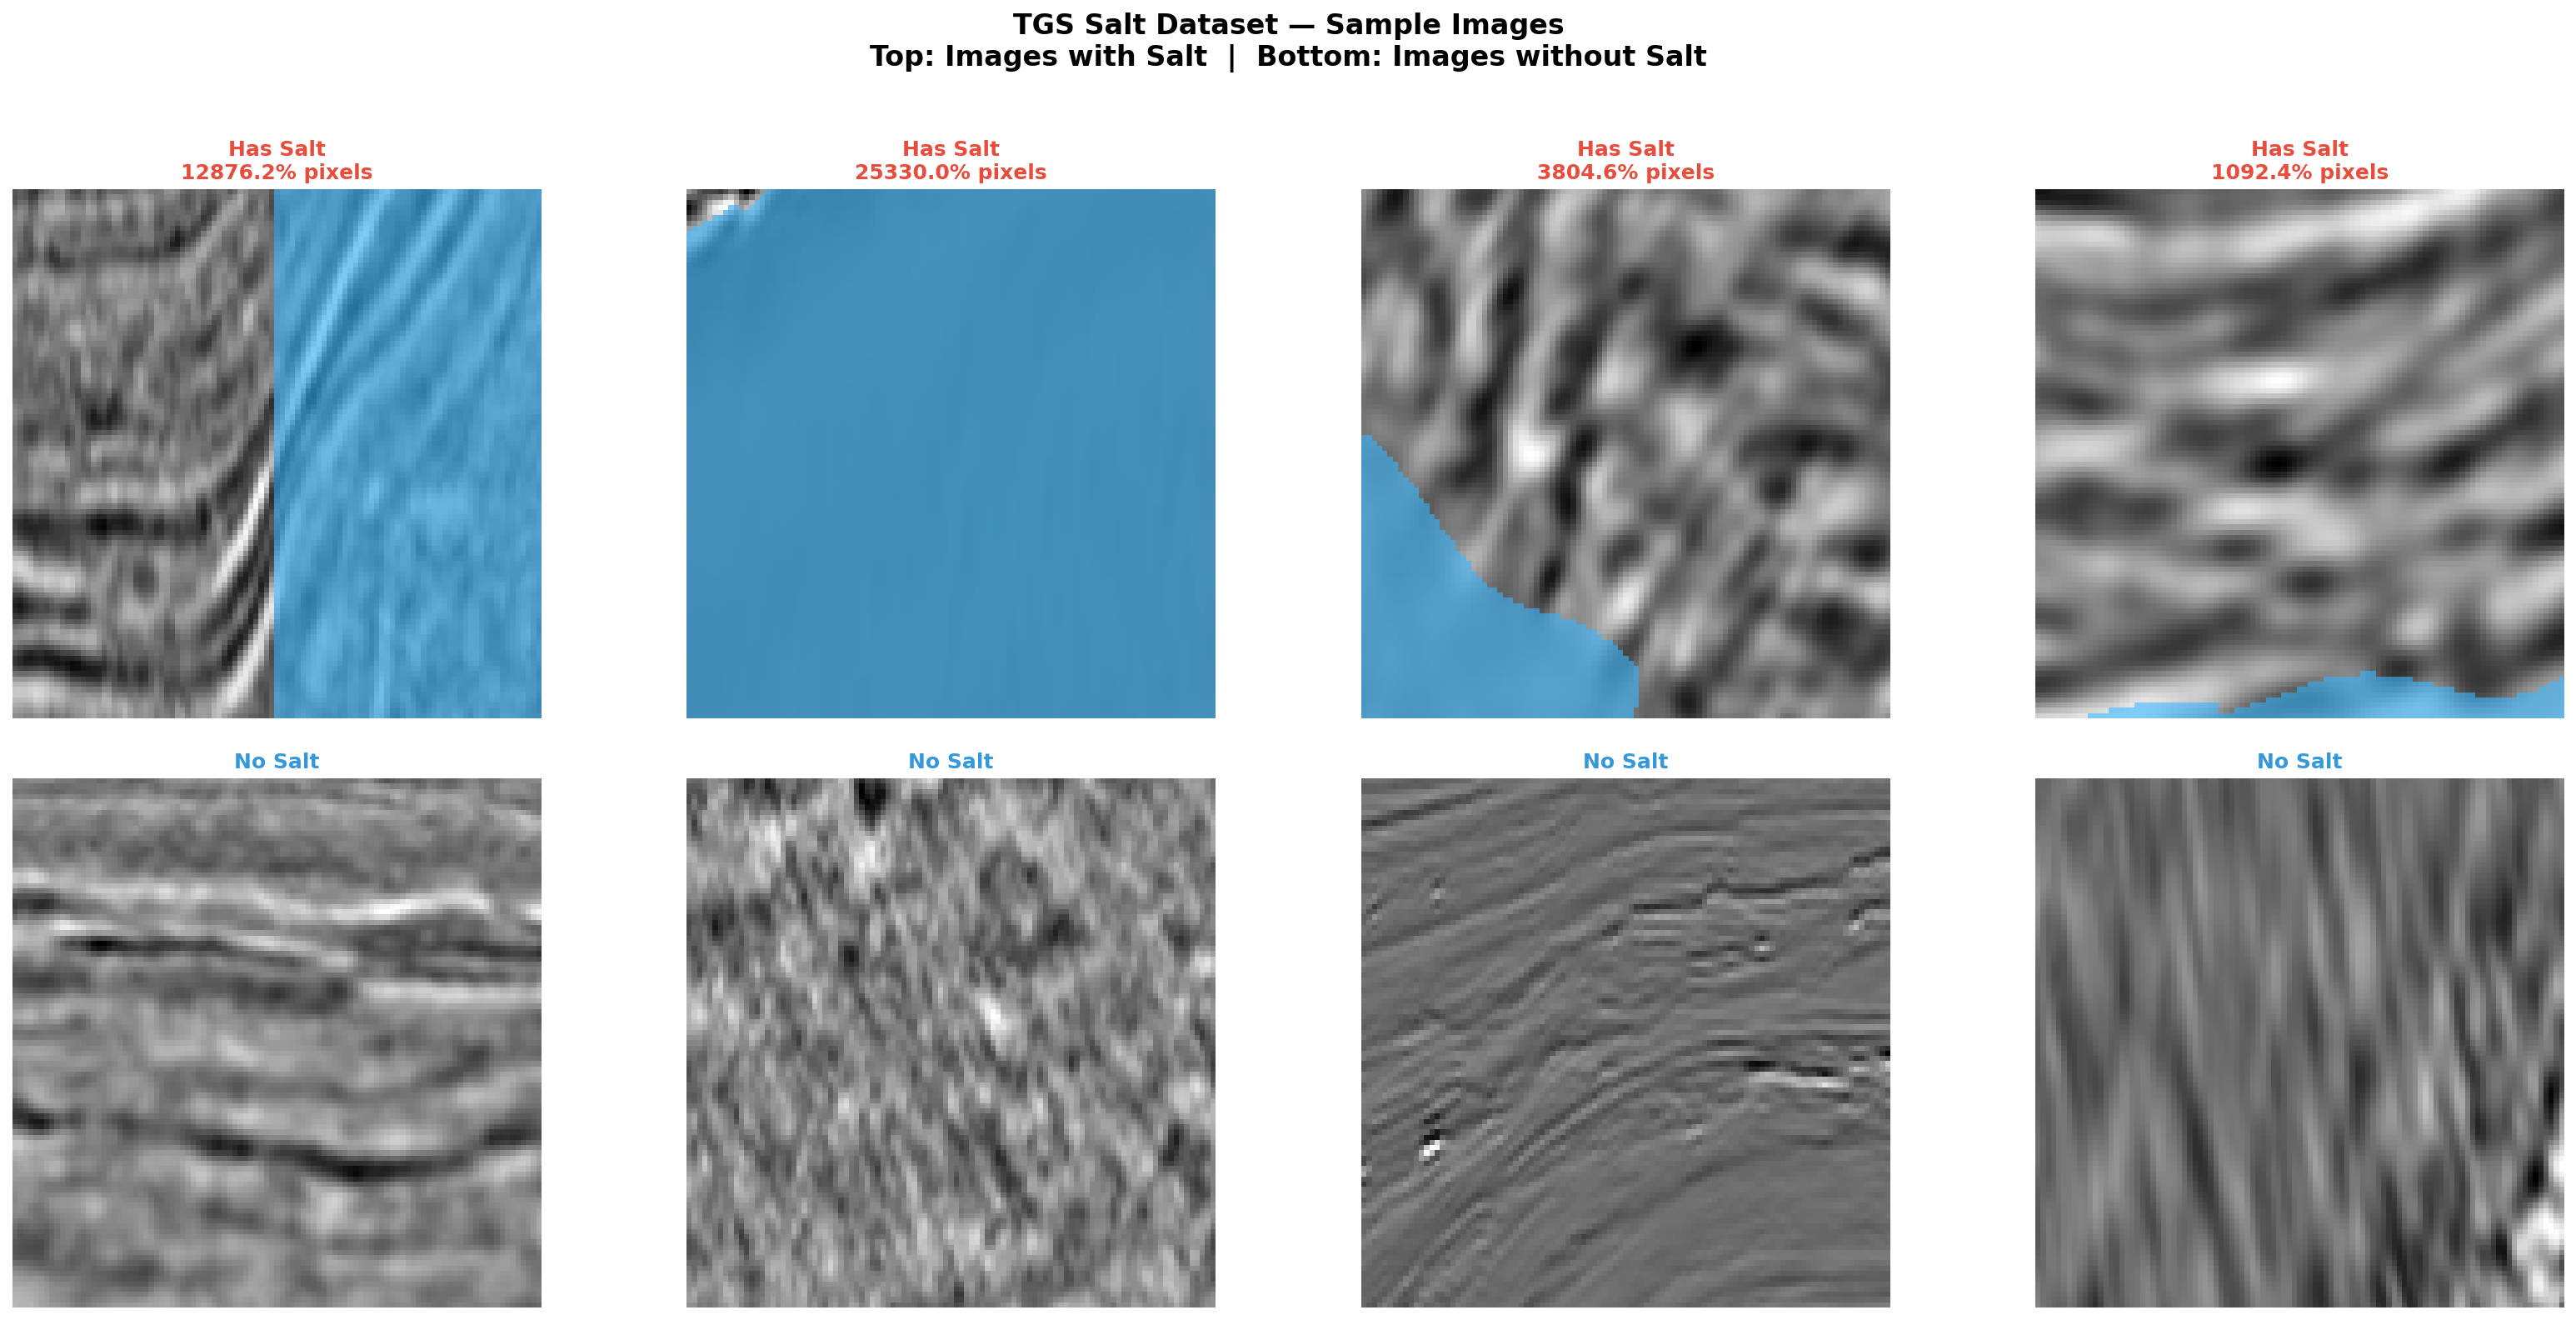

Saved samples.png


In [62]:
fig, axes = plt.subplots(2, 4, figsize=(22, 11), dpi=150)
fig.patch.set_facecolor('white')
fig.suptitle(
    'TGS Salt Dataset — Sample Images\n'
    'Top: Images with Salt  |  Bottom: Images without Salt',
    fontsize=16, fontweight='bold'
)

salt_samples  = df[df['has_salt']==True].head(4)
empty_samples = df[df['has_salt']==False].head(4)

for i, (_, row) in enumerate(salt_samples.iterrows()):
    img  = cv2.imread(os.path.join(IMGS,  f'{row["id"]}.png'))
    mask = cv2.imread(os.path.join(MASKS, f'{row["id"]}.png'),
                      cv2.IMREAD_GRAYSCALE)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    overlay = img_rgb.copy()
    overlay[mask > 0] = (
        overlay[mask > 0] * 0.4 +
        np.array([56, 182, 255]) * 0.6
    ).astype(np.uint8)
    pct = round(100 * mask.mean(), 1)
    axes[0][i].imshow(overlay)
    axes[0][i].set_title(f'Has Salt\n{pct}% pixels',
                          fontsize=12, fontweight='bold', color='#e74c3c')
    axes[0][i].axis('off')

for i, (_, row) in enumerate(empty_samples.iterrows()):
    img = cv2.imread(os.path.join(IMGS, f'{row["id"]}.png'))
    axes[1][i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), cmap='gray')
    axes[1][i].set_title('No Salt',
                          fontsize=12, fontweight='bold', color='#3498db')
    axes[1][i].axis('off')

plt.tight_layout(pad=3.0)
plt.savefig(f'{OUT}/samples.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print('Saved samples.png')

In [63]:
train_tf = A.Compose([
    A.Resize(IMG_H, IMG_W),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomBrightnessContrast(p=0.4),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1,
                       rotate_limit=15, p=0.5),
    A.OneOf([A.GaussNoise(p=1), A.GaussianBlur(p=1)], p=0.3),
    A.Normalize(mean=(0.485,0.456,0.406),
                std=(0.229,0.224,0.225)),
    ToTensorV2(),
])

val_tf = A.Compose([
    A.Resize(IMG_H, IMG_W),
    A.Normalize(mean=(0.485,0.456,0.406),
                std=(0.229,0.224,0.225)),
    ToTensorV2(),
])

print('Augmentations:')
for t in train_tf.transforms:
    print(f'  • {type(t).__name__}')

Augmentations:
  • Resize
  • HorizontalFlip
  • VerticalFlip
  • RandomBrightnessContrast
  • ShiftScaleRotate
  • OneOf
  • Normalize
  • ToTensorV2


In [ ]:
class TGSDataset(Dataset):
 
    
    def __init__(self, df, img_dir, mask_dir, transform=None):
        self.ids       = df['id'].values
        self.img_dir   = img_dir
        self.mask_dir  = mask_dir
        self.transform = transform

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        img_id = self.ids[idx]

        # Load image (RGB)
        img  = cv2.imread(os.path.join(self.img_dir, f'{img_id}.png'))
        img  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Load mask (binary: 0 or 1)
        mask = cv2.imread(os.path.join(self.mask_dir, f'{img_id}.png'),
                          cv2.IMREAD_GRAYSCALE)
        mask = (mask > 0).astype(np.float32)
        mask = mask[:, :, np.newaxis]   # add channel dim: H x W x 1

        if self.transform:
            out  = self.transform(image=img, mask=mask)
            img  = out['image']
            mask = out['mask'].permute(2, 0, 1)   # 1 x H x W
        return img, mask, img_id


# Split data
train_ids, val_ids = train_test_split(
    df['id'].values, test_size=0.15, random_state=SEED)

train_df = df[df['id'].isin(train_ids)].reset_index(drop=True)
val_df   = df[df['id'].isin(val_ids)].reset_index(drop=True)

train_ds = TGSDataset(train_df, IMGS, MASKS, train_tf)
val_ds   = TGSDataset(val_df,   IMGS, MASKS, val_tf)

train_loader = DataLoader(train_ds, batch_size=BS, shuffle=True,
                          num_workers=4, pin_memory=True, persistent_workers=True)
val_loader   = DataLoader(val_ds,   batch_size=BS, shuffle=False,
                          num_workers=4, pin_memory=True, persistent_workers=True)

print(f'Train : {len(train_ds):,} images')
print(f'Val   : {len(val_ds):,} images')

Train : 3,400 images
Val   : 600 images


In [65]:
model = smp.Unet(
    encoder_name    = 'resnet34',
    encoder_weights = 'imagenet',  # transfer learning from ImageNet
    in_channels     = 3,
    classes         = NUM_CLASSES, # 1 output channel — binary mask
    activation      = None,        # raw logits, sigmoid applied in loss
).to(device)

total_params   = sum(p.numel() for p in model.parameters())
encoder_params = sum(p.numel() for p in model.encoder.parameters())
decoder_params = sum(p.numel() for p in model.decoder.parameters())

print(f'Model          : U-Net + ResNet34 (ImageNet pretrained)')
print(f'Total params   : {total_params:,}')
print(f'Encoder params : {encoder_params:,}  (pretrained — fine-tuned)')
print(f'Decoder params : {decoder_params:,}  (trained from scratch)')

Model          : U-Net + ResNet34 (ImageNet pretrained)
Total params   : 24,436,369
Encoder params : 21,284,672  (pretrained — fine-tuned)
Decoder params : 3,151,552  (trained from scratch)


In [ ]:
class LovaszLoss(nn.Module):
    """
    Lovász loss directly optimizes IoU.

    """
    def forward(self, logits, targets):
        probs         = torch.sigmoid(logits).reshape(-1)
        targets_flat  = targets.reshape(-1)
        signs         = 2.0 * targets_flat - 1.0
        errors        = 1.0 - probs * signs
        errors_sorted, perm = torch.sort(errors, descending=True)
        gt_sorted     = targets_flat[perm]
        grad          = self._lovasz_grad(gt_sorted)
        return torch.dot(torch.relu(errors_sorted), grad)

    def _lovasz_grad(self, gt_sorted):
        p    = len(gt_sorted)
        gts  = gt_sorted.sum()
        iou  = 1.0 - (gts - gt_sorted.cumsum(0)) / \
               (gts + (1 - gt_sorted).cumsum(0)).clamp(min=1)
        grad = iou.clone()
        grad[1:p] = grad[1:p] - grad[0:p-1]
        return grad


class DiceLoss(nn.Module):
    """Dice loss = 1 - (2*overlap) / (pred + target)"""
    def forward(self, logits, targets, smooth=1.0):
        probs = torch.sigmoid(logits).reshape(-1)
        t     = targets.reshape(-1)
        inter = (probs * t).sum()
        return 1 - (2*inter + smooth) / (probs.sum() + t.sum() + smooth)


class TwoStageLoss(nn.Module):
    """

    Epochs  1-50 : BCE loss  → stable early training
    Epochs 51-60 : Dice + Lovász → directly maximize IoU
    """
    def __init__(self):
        super().__init__()
        self.bce    = nn.BCEWithLogitsLoss()
        self.dice   = DiceLoss()
        self.lovasz = LovaszLoss()
        self.epoch  = 1

    def forward(self, logits, targets):
        if self.epoch <= 50:
            return self.bce(logits, targets)
        else:
            return 0.5 * self.dice(logits, targets) + \
                   0.5 * self.lovasz(logits, targets)


def iou_score(pred, target, thr=THR, eps=1e-6):
    """IoU = intersection / union"""
    pb    = (pred > thr).float()
    inter = (pb * target).sum()
    union = pb.sum() + target.sum() - inter
    return ((inter + eps) / (union + eps)).item()


loss_fn   = TwoStageLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=EPOCHS, eta_min=1e-6)
scaler    = torch.cuda.amp.GradScaler()

print('Stage 1 (ep 1-50)  : BCE loss')
print('Stage 2 (ep 51-60) : Dice + Lovász loss')
print('Optimizer : AdamW + CosineAnnealingLR')

Stage 1 (ep 1-50)  : BCE loss
Stage 2 (ep 51-60) : Dice + Lovász loss
Optimizer : AdamW + CosineAnnealingLR


In [ ]:
def train_epoch(model, loader):
    
    # tell the model we are training 
    model.train()
    
    total = 0.0
    
    # go through each batch one by one (32 images at a time, 125 batches total)
    for imgs, masks, _ in tqdm(loader, desc='Train', leave=False):
        
        # send images and masks to GPU so model can process them
        imgs, masks = imgs.to(device, non_blocking=True), \
                      masks.to(device, non_blocking=True)
        
        # always clear old gradients before each batch — if I skip this
        # gradients from last batch will mix in and mess up the update
        optimizer.zero_grad()
        
        # run images through model and see how wrong the predictions are
        with torch.cuda.amp.autocast():  # using 16-bit math for speed
            loss = loss_fn(model(imgs), masks)
        
        # backprop — figures out how to adjust all 24M weights to reduce loss
        scaler.scale(loss).backward()
        
        # need to unscale first so clip sees the actual gradient values
        scaler.unscale_(optimizer)
        
        # safety net — if gradients explode they get capped at 1.0
        # without this training can randomly collapse especially early on
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        
        # actually update all 24M weights using the gradients we calculated
        scaler.step(optimizer)
        
        # update scaler for next batch
        scaler.update()
        
        # keep adding loss so I can return the average at the end
        total += loss.item()
    
    # average loss across all 125 batches — one number for the whole epoch
    return total / len(loader)


@torch.no_grad()  # dont track gradients — we are just checking not learning
def val_epoch(model, loader):
    
    # switch to eval mode — turns off dropout so predictions are stable
    model.eval()
    
    total, preds, masks = 0.0, [], []
    
    # go through all 600 validation images — model has never seen these
    for imgs, m, _ in tqdm(loader, desc='Val  ', leave=False):
        
        # send to GPU
        imgs, m = imgs.to(device, non_blocking=True), \
                  m.to(device, non_blocking=True)
        
        with torch.cuda.amp.autocast():
            
            # just forward pass — no backward, no weight updates here
            p = model(imgs)
            
            # track loss to see if model is improving on unseen data
            total += loss_fn(p, m).item()
        
        # save predictions and true masks — move back to CPU to save GPU memory
        preds.append(p.cpu())
        masks.append(m.cpu())
    
    # combine all batches into one big tensor — all 600 val images together
    preds = torch.cat(preds)
    masks = torch.cat(masks)
    
    # convert raw logits to probabilities first then calculate IoU
    # doing it on all 600 at once gives more accurate score than averaging per batch
    iou = round(iou_score(torch.sigmoid(preds), masks), 4)
    
    # send back avg loss, iou score, predictions and masks for plotting later
    return total/len(loader), iou, preds, masks


print('Functions ready')

Functions ready


In [68]:
best    = 0.0
ckpt    = f'{OUT}/best_model.pth'
history = {'tl':[], 'vl':[], 'iou':[]}

print(f'Training {EPOCHS} epochs on {device}')
print('Stage 1 (BCE)       : epochs 1-50')
print('Stage 2 (Dice+Lov)  : epochs 51-60')
print('='*50)

for ep in range(1, EPOCHS+1):
    loss_fn.epoch = ep   # update loss stage

    if ep == 51:
        print('\n>>> Stage 2 started: Dice + Lovász loss <<<\n')

    t0 = time.time()
    tl = train_epoch(model, train_loader)
    vl, iou, vp, vm = val_epoch(model, val_loader)
    scheduler.step()
    t  = time.time() - t0

    history['tl'].append(tl)
    history['vl'].append(vl)
    history['iou'].append(iou)

    print(f'Ep {ep:02d}/{EPOCHS}  '
          f'loss={tl:.4f}/{vl:.4f}  '
          f'IoU={iou:.4f}  '
          f'{t/60:.1f}min  '
          f'left={t*(EPOCHS-ep)/60:.0f}min')

    if iou > best:
        best = iou
        torch.save(model.state_dict(), ckpt)
        print(f'   Best: {best:.4f}')

print(f'\nDone! Best IoU: {best:.4f}')

Training 60 epochs on cuda
Stage 1 (BCE)       : epochs 1-50
Stage 2 (Dice+Lov)  : epochs 51-60


Ep 01/60  loss=0.4584/0.3736  IoU=0.5729  0.2min  left=9min
   Best: 0.5729


Ep 02/60  loss=0.3950/0.3343  IoU=0.5866  0.2min  left=10min
   Best: 0.5866


Ep 03/60  loss=0.3711/0.3449  IoU=0.5046  0.1min  left=8min


Ep 04/60  loss=0.3532/0.2744  IoU=0.6151  0.1min  left=8min
   Best: 0.6151


...

Ep 56/60  loss=0.4941/0.4588  IoU=0.8302  0.1min  left=1min


Ep 57/60  loss=0.4909/0.4594  IoU=0.8340  0.1min  left=0min


Ep 58/60  loss=0.4952/0.4556  IoU=0.8326  0.1min  left=0min


Ep 59/60  loss=0.4997/0.4572  IoU=0.8317  0.1min  left=0min


Ep 60/60  loss=0.4953/0.4595  IoU=0.8342  0.1min  left=0min

Done! Best IoU: 0.8377


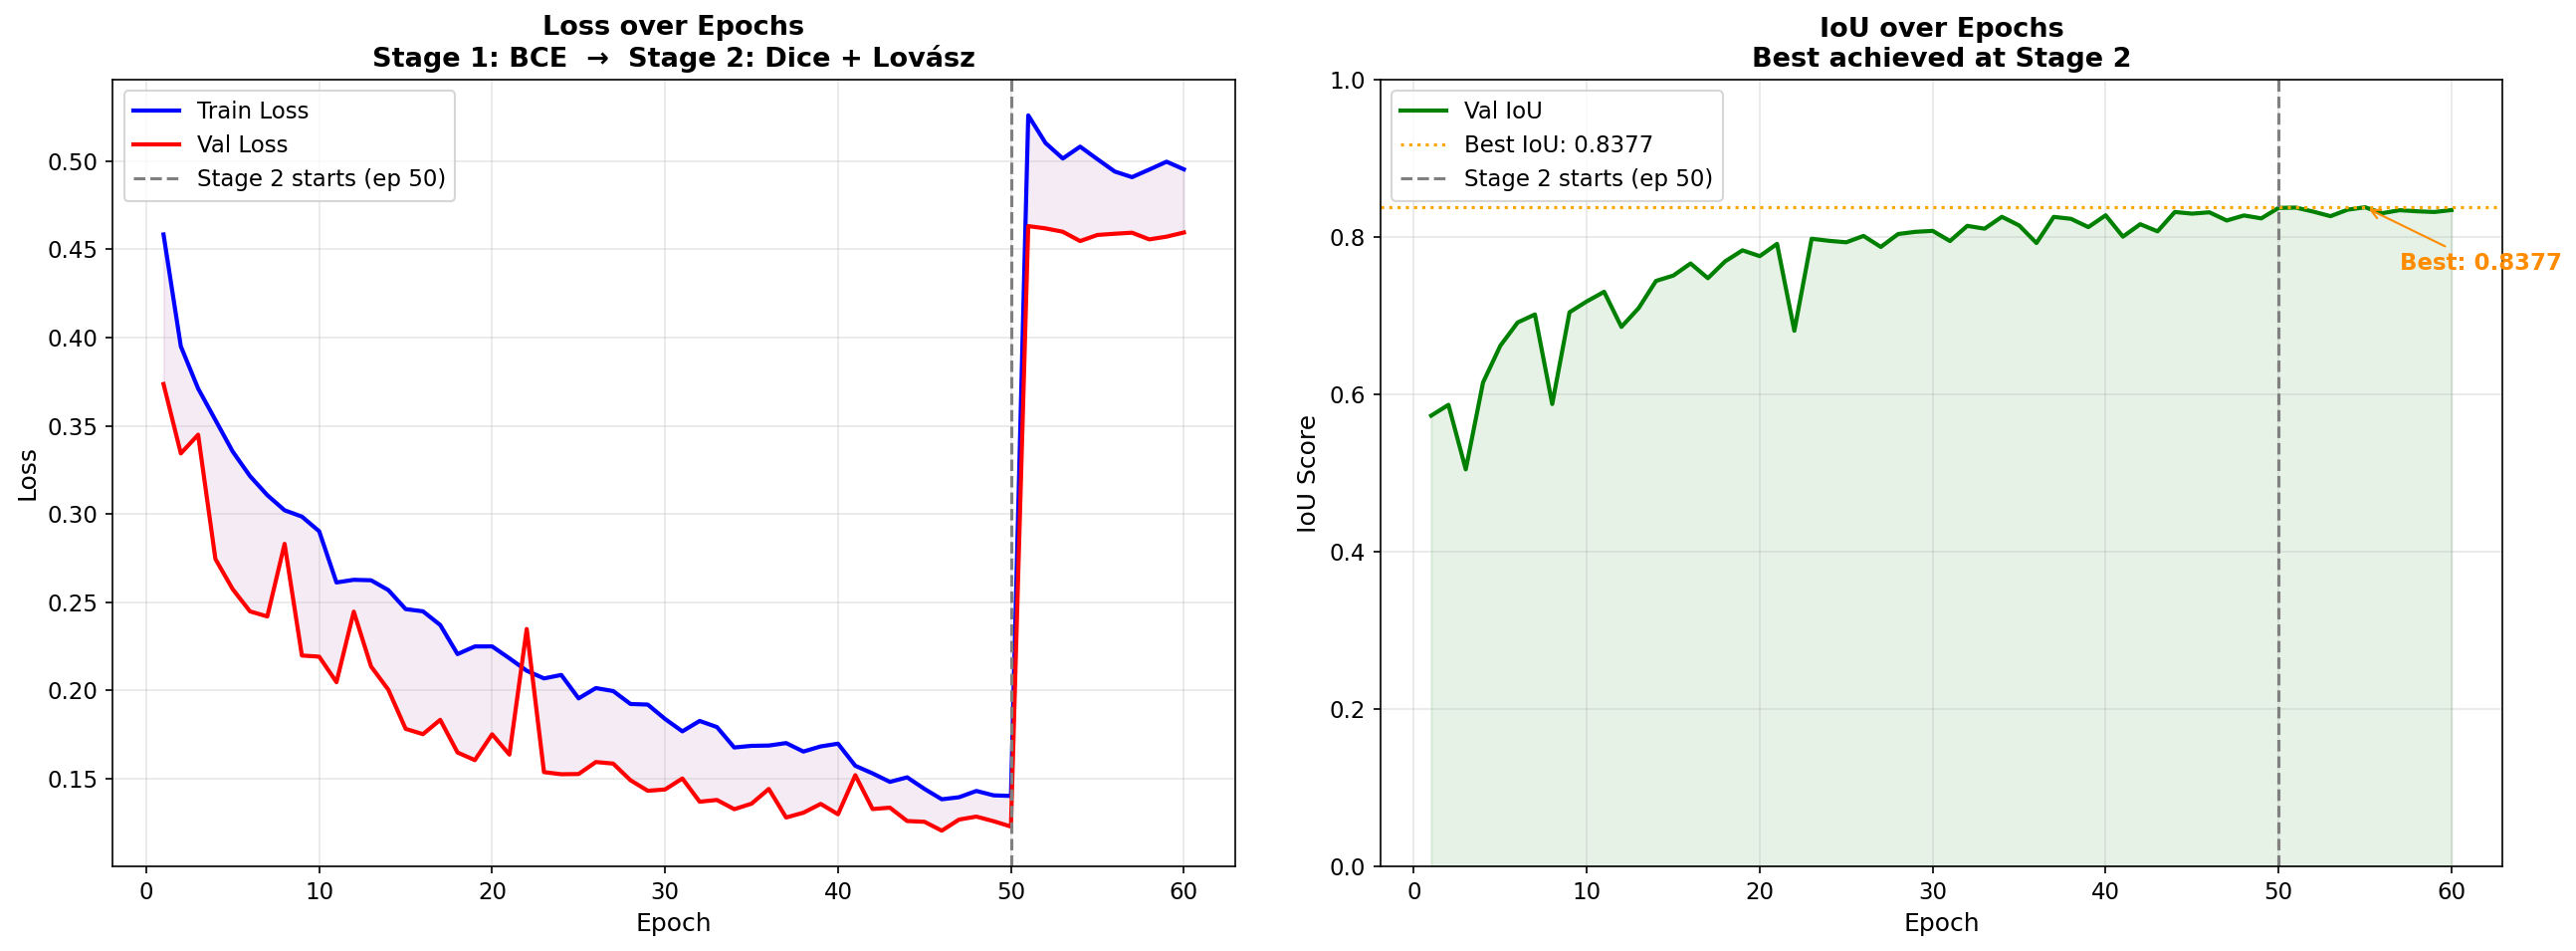

Saved curves.png


In [76]:
fig, (ax_loss, ax_iou) = plt.subplots(1, 2, figsize=(18, 7), dpi=150)
fig.patch.set_facecolor('white')

epochs = range(1, len(history['tl']) + 1)
best_ep = history['iou'].index(max(history['iou'])) + 1

# loss curves first
ax_loss.plot(epochs, history['tl'], 'b-', linewidth=2, label='Train Loss')
ax_loss.plot(epochs, history['vl'], 'r-', linewidth=2, label='Val Loss')
ax_loss.fill_between(epochs, history['tl'], history['vl'], color='purple', alpha=0.08)
ax_loss.axvline(x=50, color='gray', linestyle='--', linewidth=1.5, label='Stage 2 starts (ep 50)')
ax_loss.set_title('Loss over Epochs\nStage 1: BCE  →  Stage 2: Dice + Lovász', fontsize=13, fontweight='bold')
ax_loss.set_xlabel('Epoch', fontsize=12)
ax_loss.set_ylabel('Loss', fontsize=12)
ax_loss.legend(fontsize=11)
ax_loss.grid(alpha=0.3)
ax_loss.tick_params(labelsize=11)

# now the iou side
ax_iou.plot(epochs, history['iou'], 'g-', linewidth=2, label='Val IoU')
ax_iou.fill_between(epochs, 0, history['iou'], color='green', alpha=0.1)
ax_iou.axhline(y=best, color='orange', linestyle=':', linewidth=1.5, label=f'Best IoU: {best:.4f}')
ax_iou.axvline(x=50, color='gray', linestyle='--', linewidth=1.5, label='Stage 2 starts (ep 50)')

# little annotation pointing at the peak
ax_iou.annotate(
    f'Best: {best:.4f}',
    xy=(best_ep, best),
    xytext=(best_ep + 2, best - 0.08),
    fontsize=11, color='darkorange', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='darkorange')
)

ax_iou.set_title('IoU over Epochs\nBest achieved at Stage 2', fontsize=13, fontweight='bold')
ax_iou.set_xlabel('Epoch', fontsize=12)
ax_iou.set_ylabel('IoU Score', fontsize=12)
ax_iou.set_ylim(0, 1)
ax_iou.legend(fontsize=11)
ax_iou.grid(alpha=0.3)
ax_iou.tick_params(labelsize=11)

plt.tight_layout(pad=3.0)
plt.savefig(f'{OUT}/curves.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved curves.png')

In [70]:
# Train ResNet18 for comparison
model_r18 = smp.Unet(
    encoder_name    = 'resnet18',
    encoder_weights = 'imagenet',
    in_channels     = 3,
    classes         = CLASSES,
    activation      = None,
).to(device)

loss_fn_r18   = TwoStageLoss()
optimizer_r18 = optim.AdamW(model_r18.parameters(), lr=LR, weight_decay=1e-4)
scheduler_r18 = optim.lr_scheduler.CosineAnnealingLR(
                    optimizer_r18, T_max=EPOCHS, eta_min=1e-6)
scaler_r18    = torch.cuda.amp.GradScaler()
best_r18      = 0.0
ckpt_r18      = f'{OUT}/best_model_r18.pth'
history_r18   = {'tl':[], 'vl':[], 'iou':[]}


def train_epoch_r18(model, loader):
    model.train()
    total = 0.0
    for imgs, masks, _ in tqdm(loader, desc='Train', leave=False):
        imgs, masks = imgs.to(device, non_blocking=True), \
                      masks.to(device, non_blocking=True)
        optimizer_r18.zero_grad()
        with torch.cuda.amp.autocast():
            loss = loss_fn_r18(model(imgs), masks)
        scaler_r18.scale(loss).backward()
        scaler_r18.unscale_(optimizer_r18)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler_r18.step(optimizer_r18)
        scaler_r18.update()
        total += loss.item()
    return total / len(loader)


@torch.no_grad()
def val_epoch_r18(model, loader):
    model.eval()
    total, preds, masks = 0.0, [], []
    for imgs, m, _ in tqdm(loader, desc='Val  ', leave=False):
        imgs, m = imgs.to(device, non_blocking=True), \
                  m.to(device, non_blocking=True)
        with torch.cuda.amp.autocast():
            p = model(imgs)
            total += loss_fn_r18(p, m).item()
        preds.append(p.cpu())
        masks.append(m.cpu())
    preds = torch.cat(preds)
    masks = torch.cat(masks)
    iou   = round(iou_score(torch.sigmoid(preds), masks), 4)
    return total/len(loader), iou, preds, masks


print('Training ResNet18 for comparison')
print('='*50)

for ep in range(1, EPOCHS+1):
    loss_fn_r18.epoch = ep
    if ep == 51:
        print('\n>>> Stage 2: Dice + Lovász <<<\n')

    t0  = time.time()
    tl  = train_epoch_r18(model_r18, train_loader)
    vl, iou, vp, vm = val_epoch_r18(model_r18, val_loader)
    scheduler_r18.step()
    t   = time.time() - t0

    history_r18['tl'].append(tl)
    history_r18['vl'].append(vl)
    history_r18['iou'].append(iou)

    print(f'Ep {ep:02d}/{EPOCHS}  '
          f'loss={tl:.4f}/{vl:.4f}  '
          f'IoU={iou:.4f}  '
          f'{t/60:.1f}min  '
          f'left={t*(EPOCHS-ep)/60:.0f}min')

    if iou > best_r18:
        best_r18 = iou
        torch.save(model_r18.state_dict(), ckpt_r18)
        print(f'  Best ResNet18: {best_r18:.4f}')

print(f'\nDone ResNet18! Best IoU: {best_r18:.4f}')

Training ResNet18 for comparison


Ep 01/60  loss=0.4522/0.5994  IoU=0.1631  0.1min  left=7min
  Best ResNet18: 0.1631


Ep 02/60  loss=0.3957/0.3186  IoU=0.5826  0.1min  left=7min
  Best ResNet18: 0.5826


Ep 03/60  loss=0.3764/0.2964  IoU=0.5971  0.1min  left=7min
  Best ResNet18: 0.5971


Ep 04/60  loss=0.3488/0.3155  IoU=0.5802  0.1min  left=6min


...

Ep 56/60  loss=0.4996/0.4526  IoU=0.8342  0.1min  left=0min


Ep 57/60  loss=0.4953/0.4548  IoU=0.8381  0.1min  left=0min


Ep 58/60  loss=0.5045/0.4541  IoU=0.8357  0.1min  left=0min


Ep 59/60  loss=0.4989/0.4525  IoU=0.8328  0.1min  left=0min


Ep 60/60  loss=0.5089/0.4545  IoU=0.8370  0.1min  left=0min

Done ResNet18! Best IoU: 0.8423


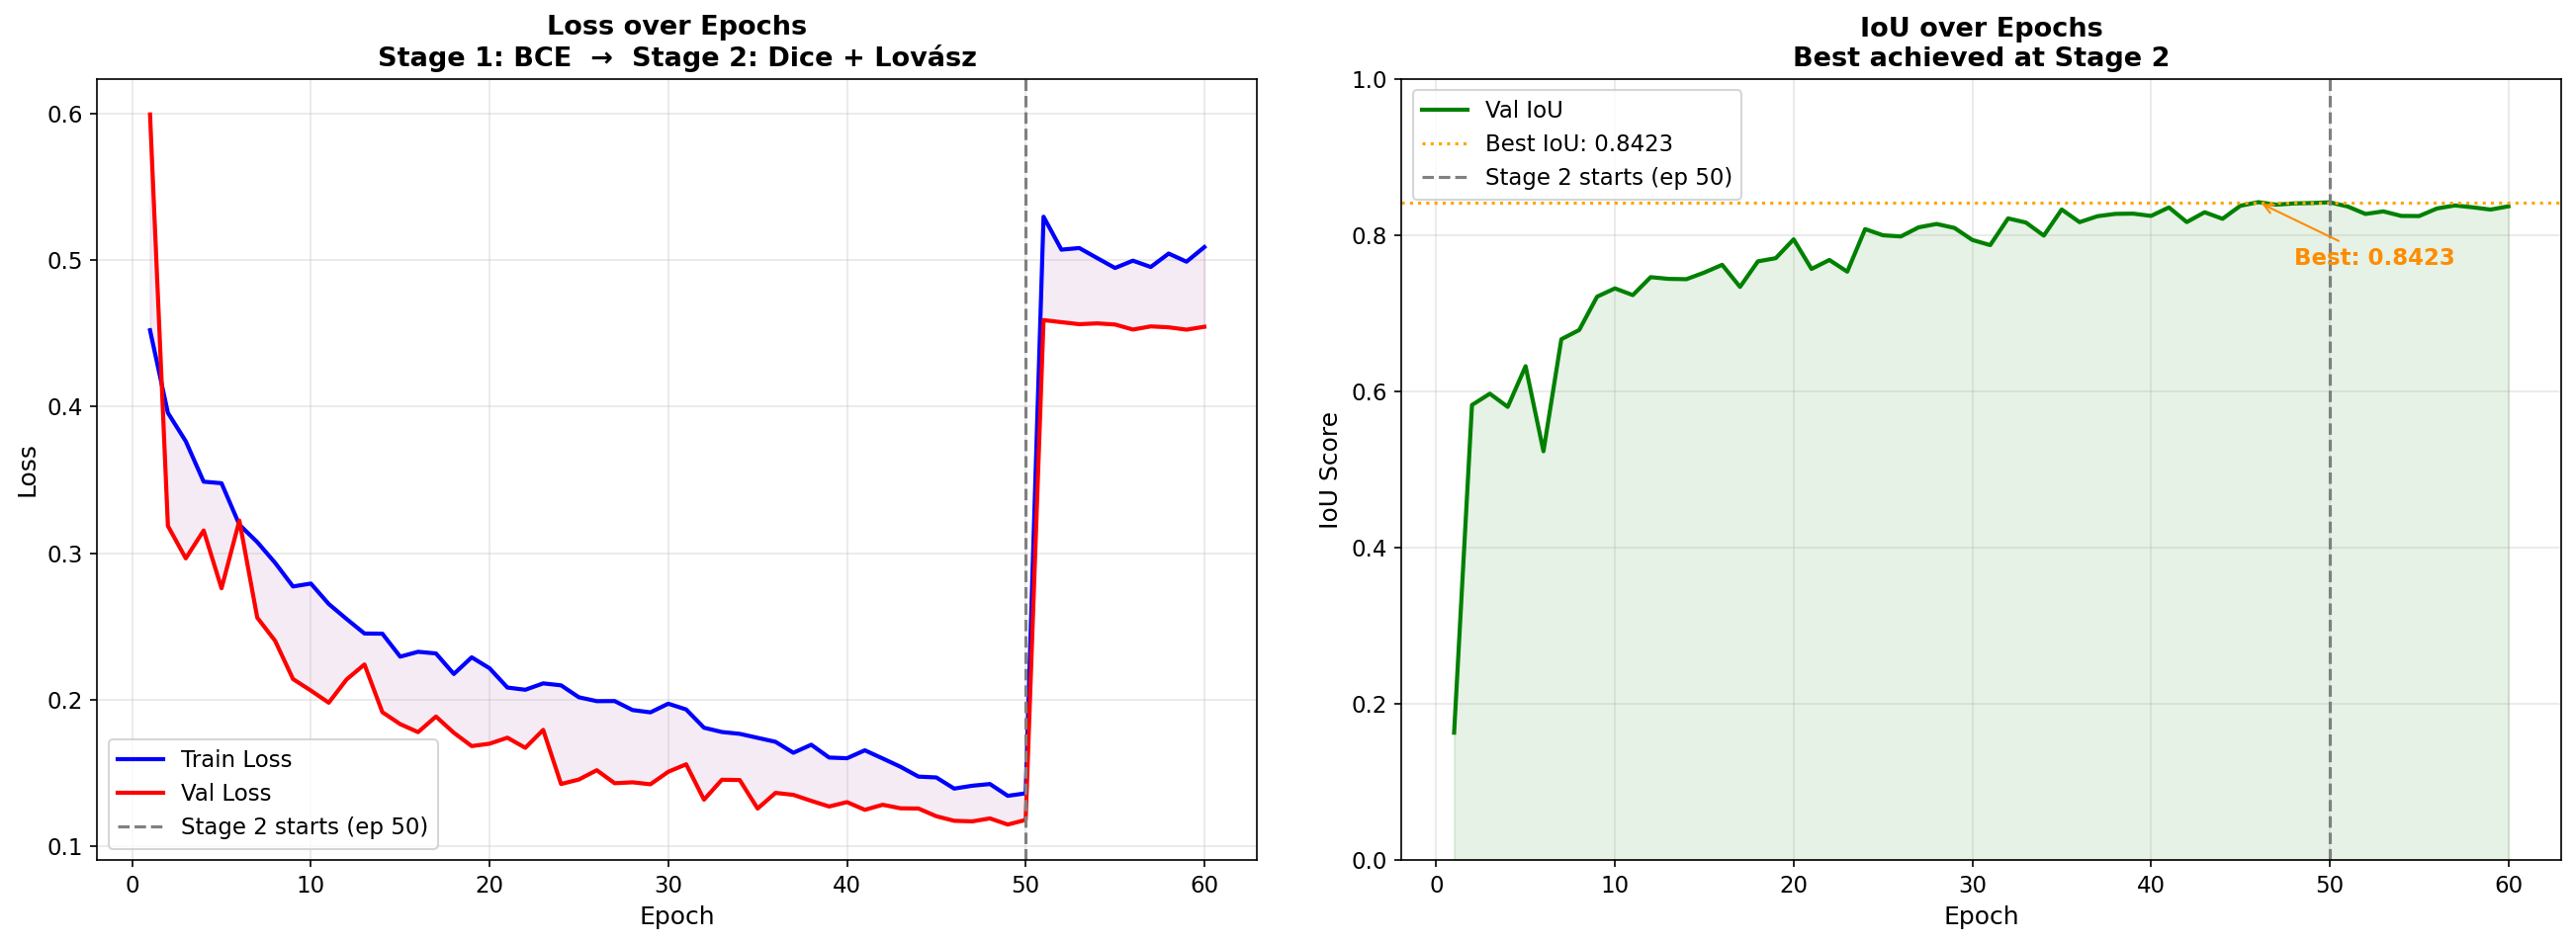

Saved curves_r18.png


In [71]:
fig, (ax_loss, ax_iou) = plt.subplots(1, 2, figsize=(18, 7), dpi=150)
fig.patch.set_facecolor('white')

epochs = range(1, len(history_r18['tl']) + 1)
best_ep = history_r18['iou'].index(max(history_r18['iou'])) + 1

# loss curves first
ax_loss.plot(epochs, history_r18['tl'], 'b-', linewidth=2, label='Train Loss')
ax_loss.plot(epochs, history_r18['vl'], 'r-', linewidth=2, label='Val Loss')
ax_loss.fill_between(epochs, history_r18['tl'], history_r18['vl'], color='purple', alpha=0.08)
ax_loss.axvline(x=50, color='gray', linestyle='--', linewidth=1.5, label='Stage 2 starts (ep 50)')
ax_loss.set_title('Loss over Epochs\nStage 1: BCE  →  Stage 2: Dice + Lovász', fontsize=13, fontweight='bold')
ax_loss.set_xlabel('Epoch', fontsize=12)
ax_loss.set_ylabel('Loss', fontsize=12)
ax_loss.legend(fontsize=11)
ax_loss.grid(alpha=0.3)
ax_loss.tick_params(labelsize=11)

# now the iou side
ax_iou.plot(epochs, history_r18['iou'], 'g-', linewidth=2, label='Val IoU')
ax_iou.fill_between(epochs, 0, history_r18['iou'], color='green', alpha=0.1)
ax_iou.axhline(y=best_r18, color='orange', linestyle=':', linewidth=1.5, label=f'Best IoU: {best_r18:.4f}')
ax_iou.axvline(x=50, color='gray', linestyle='--', linewidth=1.5, label='Stage 2 starts (ep 50)')

# little annotation pointing at the peak
ax_iou.annotate(
    f'Best: {best_r18:.4f}',
    xy=(best_ep, best_r18),
    xytext=(best_ep + 2, best_r18 - 0.08),
    fontsize=11, color='darkorange', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='darkorange')
)

ax_iou.set_title('IoU over Epochs\nBest achieved at Stage 2', fontsize=13, fontweight='bold')
ax_iou.set_xlabel('Epoch', fontsize=12)
ax_iou.set_ylabel('IoU Score', fontsize=12)
ax_iou.set_ylim(0, 1)
ax_iou.legend(fontsize=11)
ax_iou.grid(alpha=0.3)
ax_iou.tick_params(labelsize=11)

plt.tight_layout(pad=3.0)
plt.savefig(f'{OUT}/curves_r18.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved curves_r18.png')

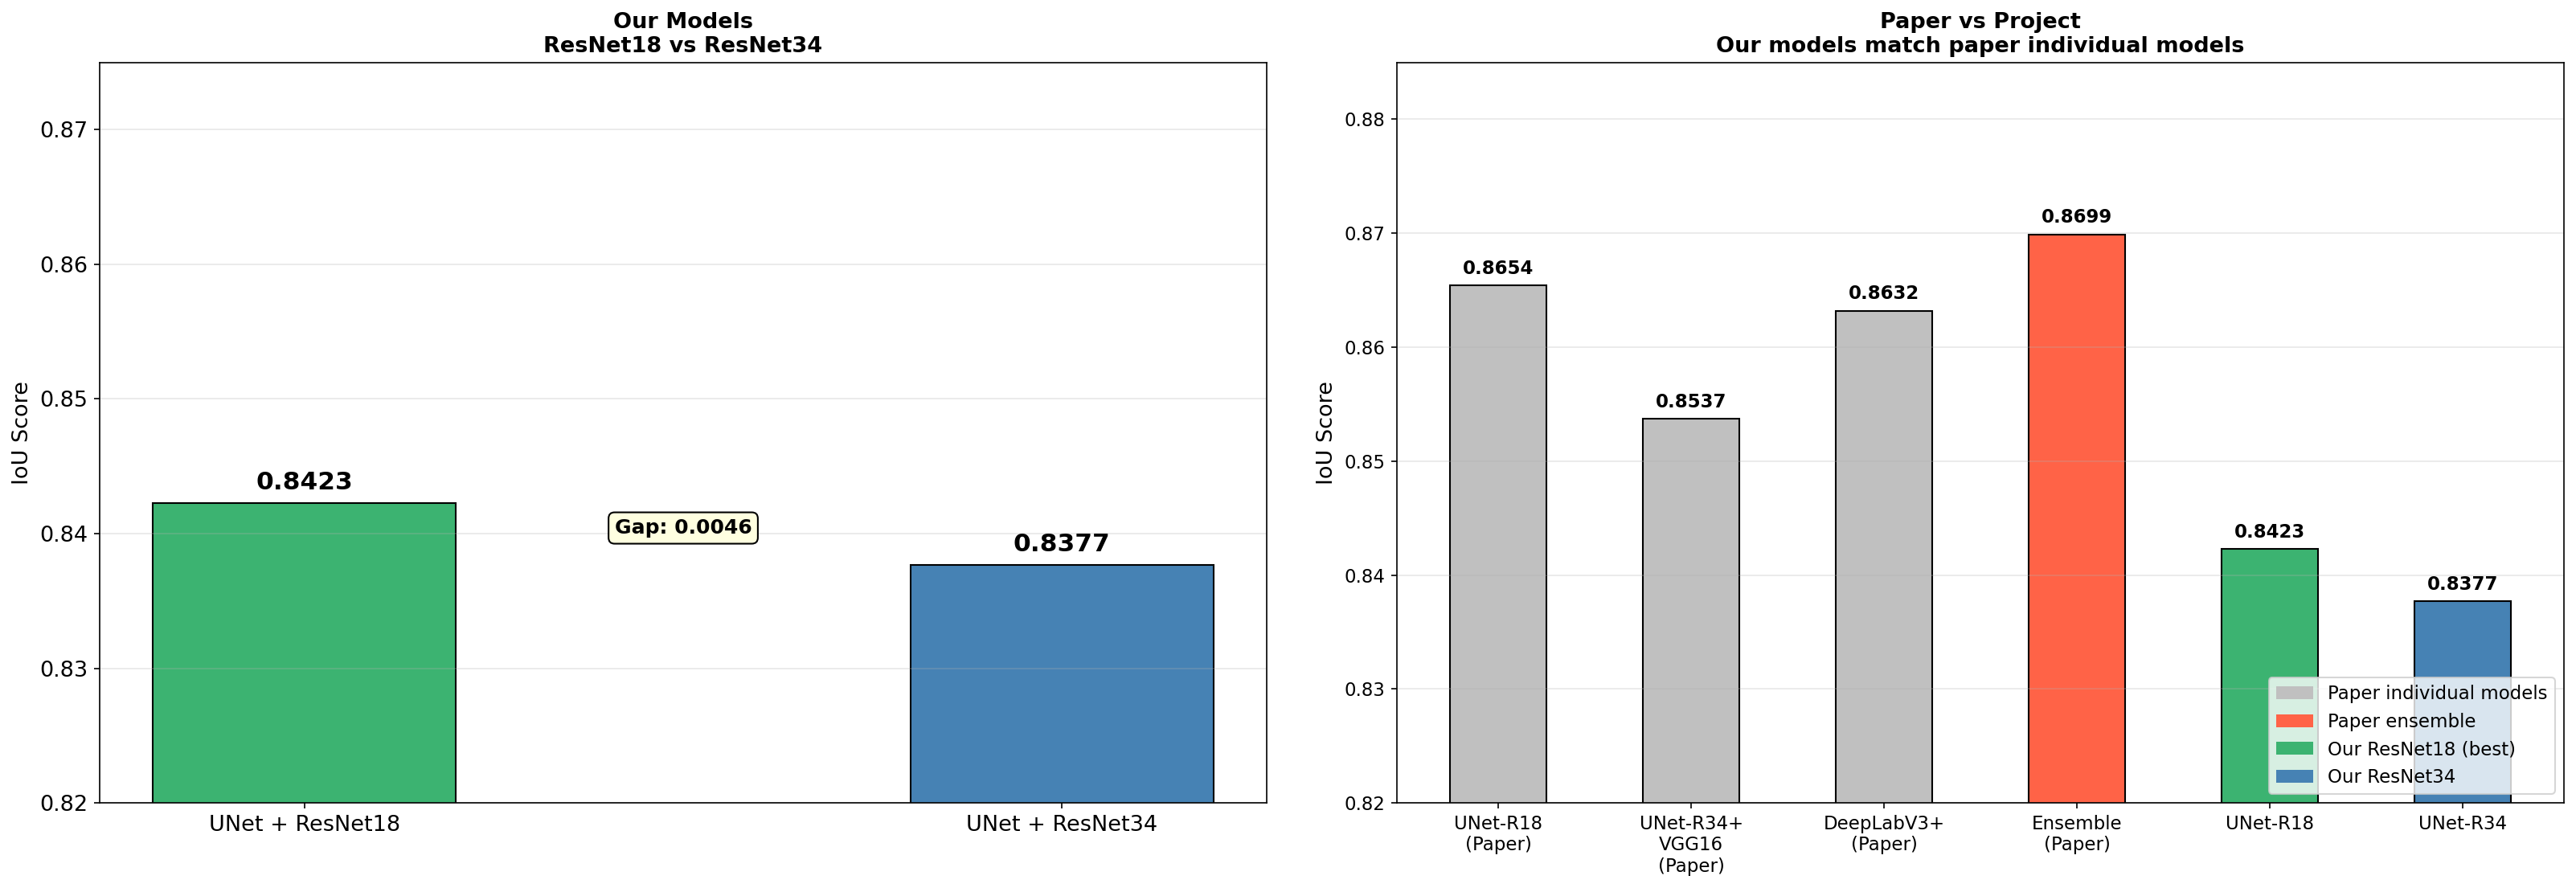

Saved comparison.png


In [72]:
fig, axes = plt.subplots(1, 2, figsize=(22, 8), dpi=150)
fig.patch.set_facecolor('white')

# our two models
models_p = ['UNet + ResNet18\n', 'UNet + ResNet34\n']
scores_p = [best_r18, best]
colors_p = ['mediumseagreen', 'steelblue']

bars = axes[0].bar(models_p, scores_p, color=colors_p, edgecolor='black', width=0.4)

for bar, val in zip(bars, scores_p):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{val:.4f}', ha='center', fontsize=15, fontweight='bold')

# gap label between the two bars
gap = round(abs(best_r18 - best), 4)
axes[0].text(0.5, (best_r18 + best)/2, f'Gap: {gap:.4f}',
    ha='center', fontsize=12, fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='black'))

axes[0].set_title('Our Models\nResNet18 vs ResNet34', fontsize=13, fontweight='bold')
axes[0].set_ylabel('IoU Score', fontsize=13)
axes[0].set_ylim(0.82, 0.875)
axes[0].tick_params(labelsize=13)
axes[0].grid(alpha=0.3, axis='y')

# comparing against the paper numbers
models_all = ['UNet-R18\n(Paper)', 'UNet-R34+\nVGG16\n(Paper)',
              'DeepLabV3+\n(Paper)', 'Ensemble\n(Paper)', 'UNet-R18\n', 'UNet-R34\n']
scores_all = [0.8654, 0.8537, 0.8632, 0.8699, best_r18, best]
colors_all = ['silver', 'silver', 'silver', 'tomato', 'mediumseagreen', 'steelblue']

bars2 = axes[1].bar(models_all, scores_all, color=colors_all, edgecolor='black', width=0.5)

for bar, val in zip(bars2, scores_all):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')

axes[1].set_title('Paper vs Project\nOur models match paper individual models',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('IoU Score', fontsize=13)
axes[1].set_ylim(0.82, 0.885)
axes[1].tick_params(labelsize=11)
axes[1].grid(alpha=0.3, axis='y')

from matplotlib.patches import Patch
axes[1].legend(handles=[
    Patch(facecolor='silver',         label='Paper individual models'),
    Patch(facecolor='tomato',         label='Paper ensemble'),
    Patch(facecolor='mediumseagreen', label='Our ResNet18 (best)'),
    Patch(facecolor='steelblue',      label='Our ResNet34'),
], fontsize=11, loc='lower right')

plt.tight_layout(pad=3.0)
plt.savefig(f'{OUT}/comparison.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved comparison.png')

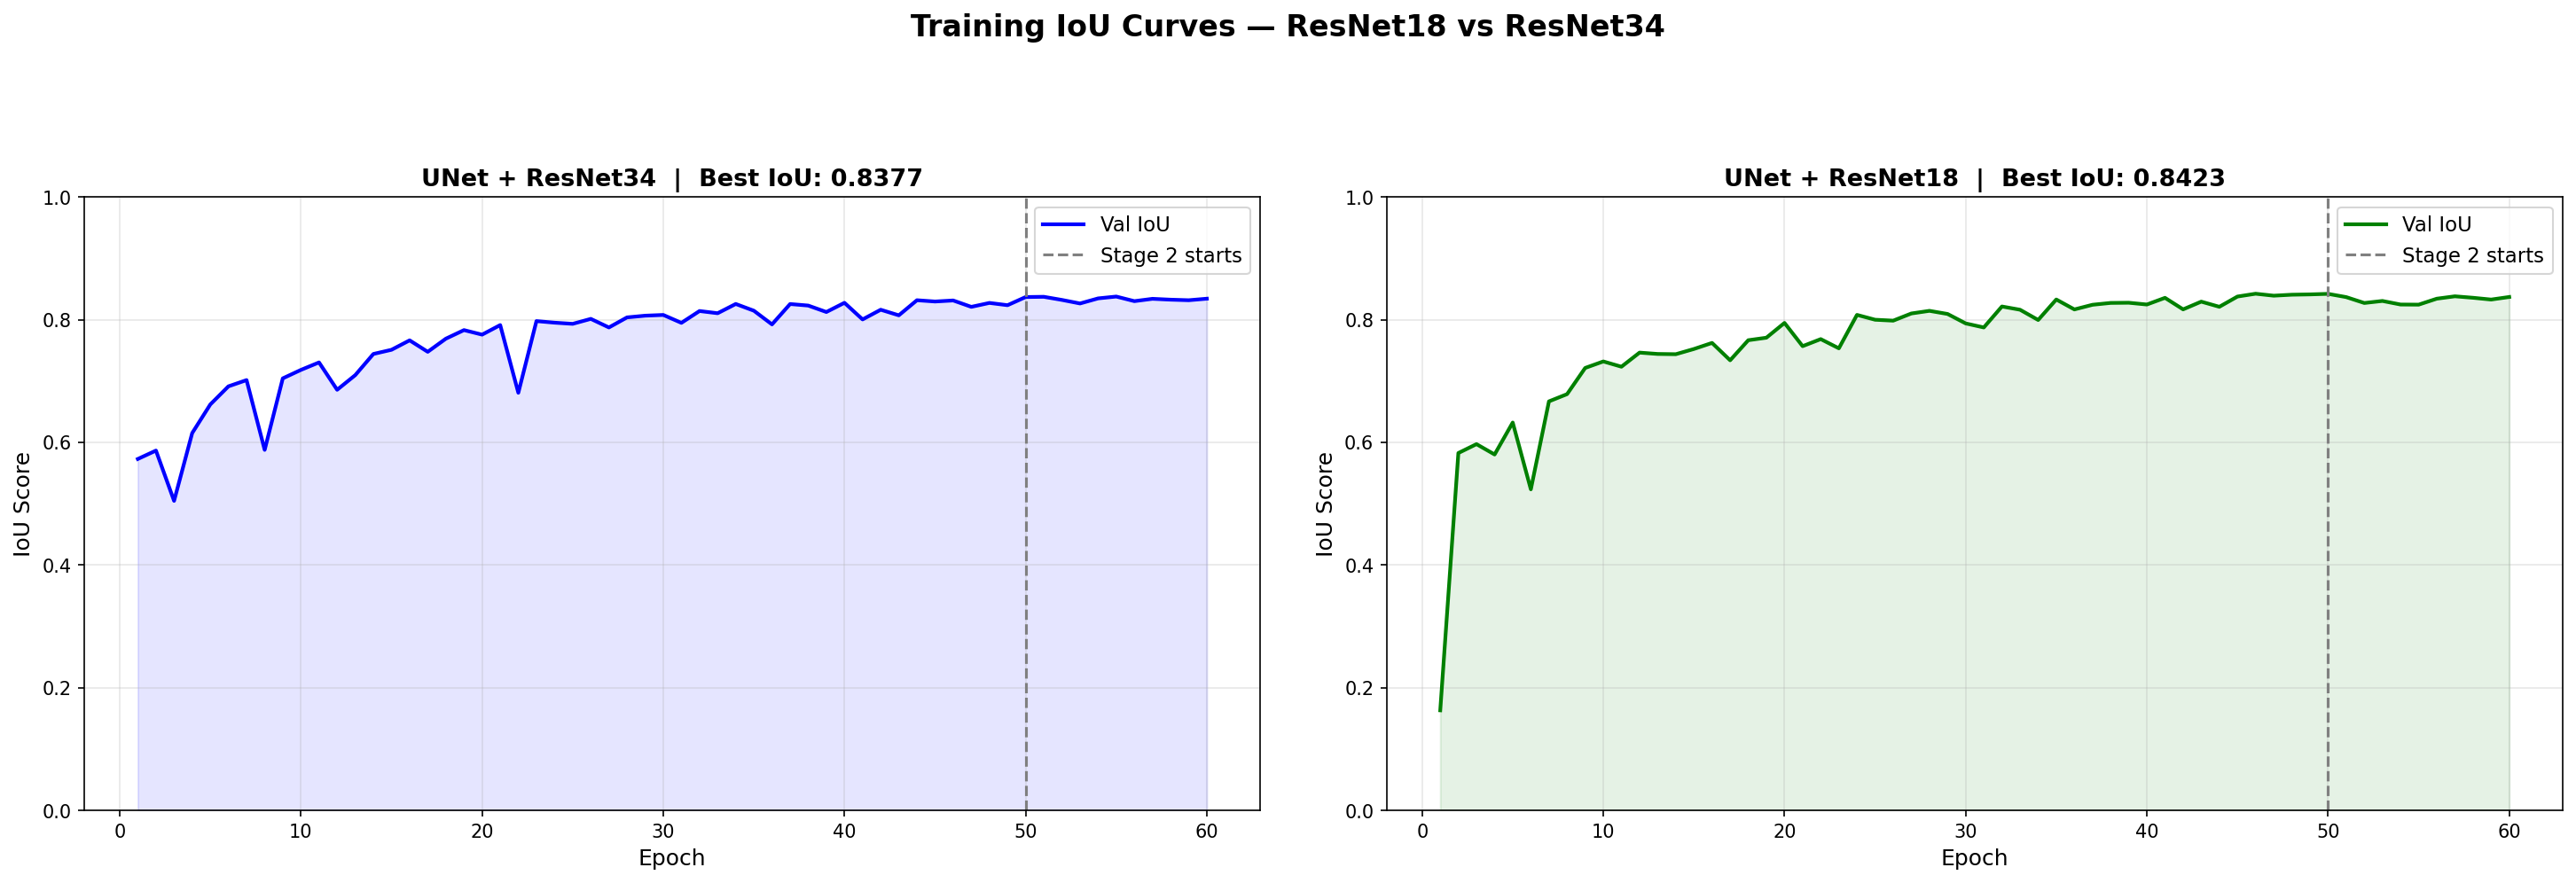

Saved iou_curves_comparison.png


In [73]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7), dpi=150)
fig.patch.set_facecolor('white')
fig.suptitle('Training IoU Curves — ResNet18 vs ResNet34\n', fontsize=16, fontweight='bold')

ep34 = range(1, len(history['iou']) + 1)
ep18 = range(1, len(history_r18['iou']) + 1)

# resnet34
axes[0].plot(ep34, history['iou'], 'b-', linewidth=2, label='Val IoU')
axes[0].axvline(x=50, color='gray', linestyle='--', linewidth=1.5, label='Stage 2 starts')
axes[0].fill_between(ep34, 0, history['iou'], alpha=0.1, color='blue')
axes[0].set_title(f'UNet + ResNet34  |  Best IoU: {best:.4f}', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('IoU Score', fontsize=12)
axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# resnet18
axes[1].plot(ep18, history_r18['iou'], 'g-', linewidth=2, label='Val IoU')
axes[1].axvline(x=50, color='gray', linestyle='--', linewidth=1.5, label='Stage 2 starts')
axes[1].fill_between(ep18, 0, history_r18['iou'], alpha=0.1, color='green')
axes[1].set_title(f'UNet + ResNet18  |  Best IoU: {best_r18:.4f}', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('IoU Score', fontsize=12)
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.tight_layout(pad=3.0)
plt.savefig(f'{OUT}/iou_curves_comparison.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved iou_curves_comparison.png')

In [74]:
print('=' * 60)
print('  FINAL RESULTS ')


print('=' * 60)
print(f'  UNet + ResNet18 : {best_r18:.4f} ')
print(f'  UNet + ResNet34 : {best:.4f}')
print(f'  Paper Ensemble  : 0.8699')
print('=' * 60)

print()
print('GitHub README table:')
print('| Model            | IoU    |')
print('|------------------|--------|')
print(f'| UNet + ResNet18  | {best_r18:.4f} |')
print(f'| UNet + ResNet34  | {best:.4f} |')
print(f'| Paper Ensemble   | 0.8699 |')

  FINAL RESULTS 
  UNet + ResNet18 : 0.8423 
  UNet + ResNet34 : 0.8377
  Paper Ensemble  : 0.8699

GitHub README table:
| Model            | IoU    |
|------------------|--------|
| UNet + ResNet18  | 0.8423 |
| UNet + ResNet34  | 0.8377 |
| Paper Ensemble   | 0.8699 |
